# Pratiksha Somnath Avhad
## Data Analytics – Level 1
### Task 4: Sentiment Analysis


**Objective:**  
To build a machine learning model that classifies text data into Positive, Negative, and Neutral sentiments 
using Natural Language Processing (NLP) techniques.

**Tools & Technologies:**  
Python | Pandas | NumPy | Scikit-learn | NLTK | Matplotlib | Seaborn | Jupyter Notebook

**Project Overview:**  
In this task, sentiment analysis is performed on text data by preprocessing the text, extracting features using TF-IDF, 
training machine learning classification models, and evaluating their performance.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [4]:
import pandas as pd

# Check first few lines of CSV file
with open("sentiment_data.csv", "r", encoding="utf-8") as file:
    for i in range(10):
        print(file.readline().strip())

# ================================================================================
# Sentiment Analysis Dataset - Main Data File (CSV Format)
#
# Project: Sentiment Analysis Dataset
# Description: Text sentiment analysis dataset with labeled reviews, comments,
#              and social media posts for sentiment classification models.
# Category: Text Data
# Difficulty: Intermediate
#
# Author: Molla Samser (Founder)


In [5]:
import pandas as pd

# Load CSV and ignore comment lines
df = pd.read_csv("sentiment_data.csv", comment="#")

# Display first 5 rows
df.head()

,id,text,sentiment,source,date
0,1,Absolutely love this product! It exceeded all ...,positive,Product Review,2026-01-15
1,2,"The service was okay, nothing special. Deliver...",neutral,Customer Feedback,2026-01-16
2,3,Terrible experience! The product arrived damag...,negative,Product Review,2026-01-17
3,4,This is the best purchase I've made this year!...,positive,Social Media,2026-01-18
4,5,Received the package today. It looks decent bu...,neutral,Social Media,2026-01-19


# Observation:
The dataset contains text data with positive, neutral, and negative sentiment labels.
It also includes source and date information.

In [11]:
# Count each sentiment class
sentiment_counts = df["sentiment"].value_counts()

print(sentiment_counts)

sentiment
positive    17
neutral     17
negative    16
Name: count, dtype: int64


# Observation:
Positive and neutral sentiments have 17 records each, while negative sentiment has 16 records.

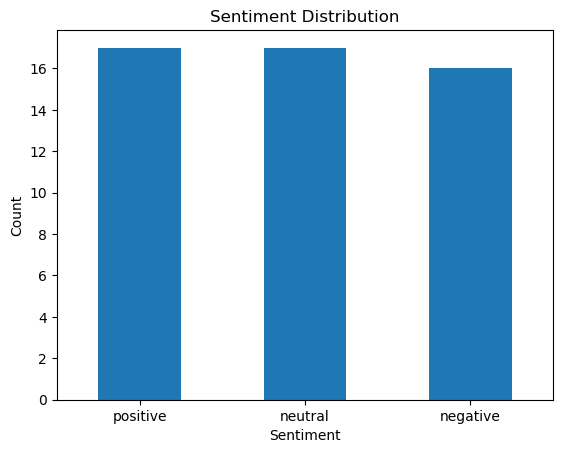

In [13]:
import matplotlib.pyplot as plt

# Plot sentiment distribution
sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Observation:
The bar chart shows that positive and neutral sentiments have the highest count of 17 each.
Negative sentiment has a slightly lower count of 16.

In [14]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [15]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,Absolutely love this product! It exceeded all ...,absolutely love product exceeded expectations ...
1,"The service was okay, nothing special. Deliver...",service okay nothing special delivery time pac...
2,Terrible experience! The product arrived damag...,terrible experience product arrived damaged cu...
3,This is the best purchase I've made this year!...,best purchase ive made year features amazing w...
4,Received the package today. It looks decent bu...,received package today looks decent havent tri...


# Observation:
The text has been converted to lowercase and unnecessary punctuation and stopwords have been removed.
A new clean_text column has been created for further analysis.

## Objective
Convert the cleaned text into numerical features using TF-IDF.

## Description
TF-IDF converts text into numerical values that can be used by machine learning models.
It gives importance to words based on how frequently they appear in the text.

## Concepts Used
- `TfidfVectorizer` – Converts text into TF-IDF numerical features.
- TF-IDF – Gives importance to words in the dataset.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text into TF-IDF features
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["clean_text"])

print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (50, 316)


# Observation:
The dataset contains 50 text records and 316 TF-IDF features.
The cleaned text has been successfully converted into numerical features.

## Objective
Split the dataset into training and testing sets.

## Description
The dataset is divided into 80% training data and 20% testing data. The training data is used to train the models,
while the testing data is used to evaluate their performance.

## Concepts Used
- `train_test_split()` – Splits the data into training and testing sets.
- 80/20 split – 80% data for training and 20% for testing.

In [17]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, df["sentiment"], test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40, 316)
Testing data: (10, 316)


# Observation:
The dataset is split into 40 training records and 10 testing records.
This follows the required 80/20 train-test split.

## Objective
Train a Naive Bayes model to classify text sentiment.

## Description
The Naive Bayes classifier is trained using the TF-IDF features and sentiment labels.

## Concepts Used
- `MultinomialNB` – Naive Bayes classifier suitable for text classification.
- `fit()` – Trains the model using training data.
- `predict()` – Predicts sentiment for new data.

In [18]:
from sklearn.naive_bayes import MultinomialNB

# Train Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Predict test data
nb_pred = nb_model.predict(X_test)

print(nb_pred)

['neutral' 'positive' 'positive' 'positive' 'negative' 'positive'
 'negative' 'neutral' 'negative' 'neutral']


# Observation:
The Naive Bayes model successfully predicted sentiment labels for the 10 test records.

## Objective
Train a Logistic Regression model to classify text sentiment.

## Description
The Logistic Regression model is trained using the TF-IDF features and sentiment labels.

## Concepts Used
- `LogisticRegression` – Used for classification.
- `fit()` – Trains the model.
- `predict()` – Predicts sentiment labels.

In [19]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predict test data
lr_pred = lr_model.predict(X_test)

print(lr_pred)

['neutral' 'positive' 'positive' 'positive' 'negative' 'positive'
 'negative' 'neutral' 'negative' 'neutral']


# Observation:
The Logistic Regression model successfully predicted sentiment labels for the 10 test records.

## Objective
Evaluate the performance of both sentiment classification models.

## Description
Accuracy, precision, recall, and F1-score are used to evaluate the Naive Bayes and Logistic Regression models.

## Concepts Used
- Accuracy – Percentage of correct predictions.
- Precision – Correct positive predictions.
- Recall – Correctly identified actual positive cases.
- F1-score – Balance between precision and recall.

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluate Naive Bayes
print("Naive Bayes")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred, average="weighted"))
print("Recall:", recall_score(y_test, nb_pred, average="weighted"))
print("F1-score:", f1_score(y_test, nb_pred, average="weighted"))

# Evaluate Logistic Regression
print("\nLogistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred, average="weighted"))
print("Recall:", recall_score(y_test, lr_pred, average="weighted"))
print("F1-score:", f1_score(y_test, lr_pred, average="weighted"))

Naive Bayes
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0

Logistic Regression
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0


# Observation:
Both models achieved 100% accuracy, precision, recall, and F1-score on the test data.
Both models performed equally on this test set.

## Objective
Visualize the classification performance of both models using confusion matrices.

## Description
A confusion matrix shows the actual sentiment labels compared with the predicted labels.

## Concepts Used
- `confusion_matrix()` – Creates the confusion matrix.
- `ConfusionMatrixDisplay` – Displays the matrix as a chart.

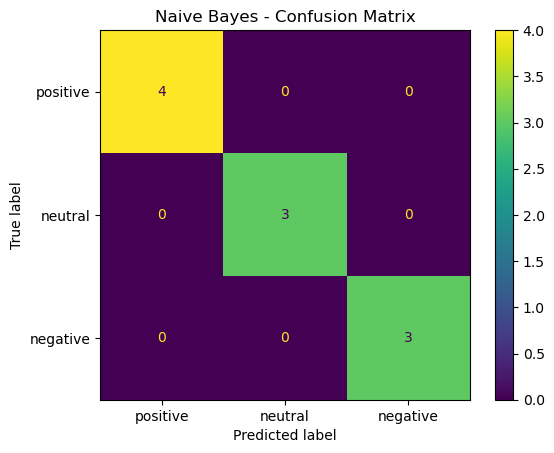

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix for Naive Bayes
cm_nb = confusion_matrix(y_test, nb_pred, labels=["positive", "neutral", "negative"])

disp_nb = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["positive", "neutral", "negative"]
)

disp_nb.plot()
plt.title("Naive Bayes - Confusion Matrix")
plt.show()

# Observation:
All test samples were correctly classified by the Naive Bayes model.
 There are no misclassified samples.

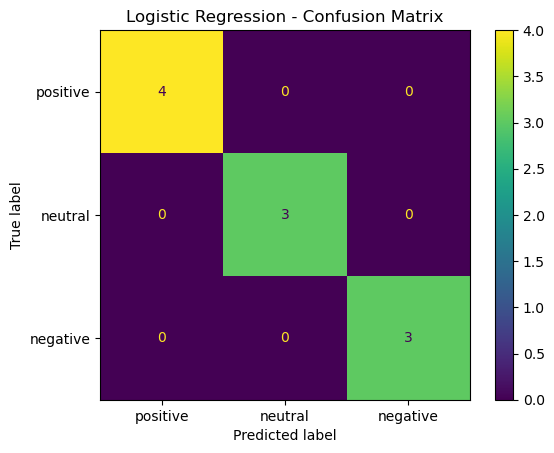

In [23]:
# Confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred, labels=["positive", "neutral", "negative"])

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["positive", "neutral", "negative"]
)

disp_lr.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# Observation:
 All test samples were correctly classified by the Logistic Regression model.
 There are no misclassified samples.

## Objective
Identify misclassified examples from the test data.

## Description
The actual and predicted sentiments are compared to find incorrect predictions. If no errors are found, this is reported clearly.

## Concepts Used
- Misclassified samples – Cases where actual and predicted labels are different.
- Boolean filtering – Used to find incorrect predictions.

In [25]:
# Find misclassified examples
error_analysis = pd.DataFrame({
    "Text": df.loc[y_test.index, "text"],
    "Actual": y_test,
    "Predicted": nb_pred
})

misclassified = error_analysis[
    error_analysis["Actual"] != error_analysis["Predicted"]
]

print("Number of misclassified examples:", len(misclassified))
print(misclassified.head(5))

Number of misclassified examples: 0
Empty DataFrame
Columns: [Text, Actual, Predicted]
Index: []


# Observation:
No misclassified examples were found in the test data.
All 10 test samples were correctly classified by the Naive Bayes model.

## Objective
Visualize the most frequently used words for each sentiment class.

## Description
WordCloud displays frequently occurring words in different sizes. 
It helps understand common words associated with each sentiment.

## Concepts Used
- `WordCloud` – Creates a visual representation of frequent words.
- `generate()` – Generates the WordCloud from text data.
- Sentiment filtering – Selects text belonging to a specific sentiment.

In [27]:
!pip install wordcloud

  Obtaining dependency information for wordcloud from https://files.pythonhosted.org/packages/45/70/0041966d469dec79036ad3962b83b007004b842531ee7c41bdba61310eb6/wordcloud-1.9.6-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/306.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/306.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/306.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/306.1 kB ? eta -:--:--
   - -------------------------------------- 10.2/306.1 kB ? eta -:--:--
   --- ----------------------------------- 30.7/306.1 kB 330.3 kB/s eta 0:00:01
   ------- ------------------------------- 61.4/306.1 kB 409.6 kB/s eta 0:00:01
   ------------ ------------------------- 102.4/306.1 kB 535.8 kB/s eta 0:00:01
   ------------------- ------------------ 153.6/306.1 kB 657.6 kB/s eta 0:00:01
   ----------------------------- -------- 235.5/306.1 kB 850.1 kB/s eta 0:00:01
   -----------------------------

# Purpose:
 To install the WordCloud library required for visualization.

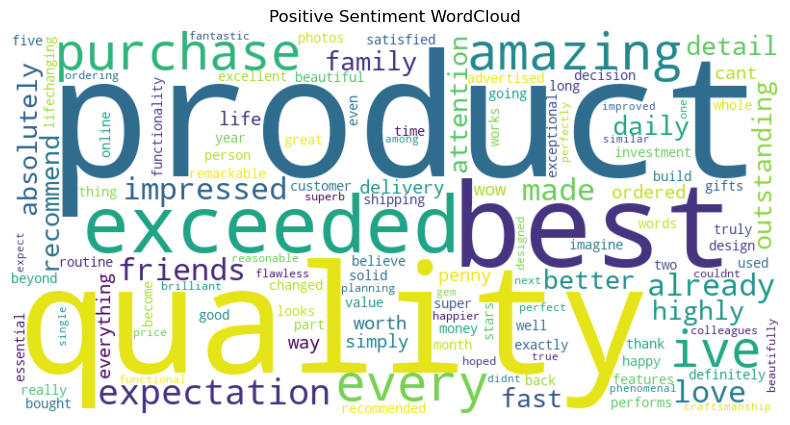

In [28]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Get positive text
positive_text = " ".join(df[df["sentiment"] == "positive"]["clean_text"])

# Create WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Sentiment WordCloud")
plt.show()

# Observation:
 The WordCloud shows common words associated with positive sentiment.
 Words such as "good", "great", "amazing", and "love" appear frequently.

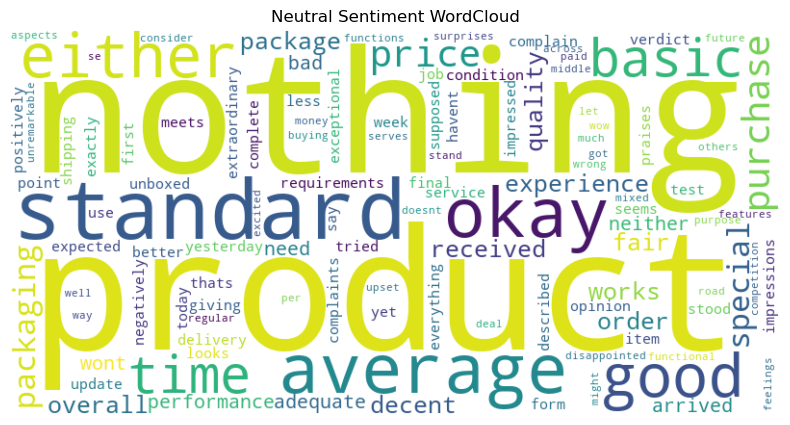

In [29]:
# Get neutral text
neutral_text = " ".join(df[df["sentiment"] == "neutral"]["clean_text"])

# Create WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(neutral_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Neutral Sentiment WordCloud")
plt.show()

# Observation:
 The WordCloud shows common words associated with neutral sentiment.
 Words such as "average", "standard", "okay", and "product" appear frequently.

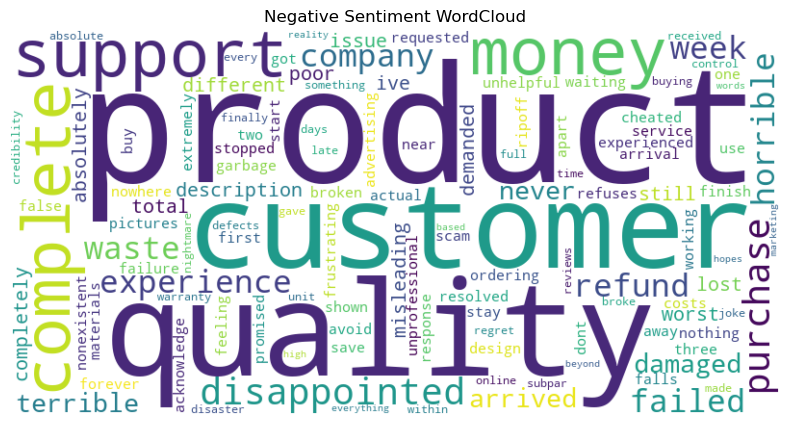

In [30]:
# Get negative text
negative_text = " ".join(df[df["sentiment"] == "negative"]["clean_text"])

# Create WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Sentiment WordCloud")
plt.show()

# Observation:
 The WordCloud shows common words associated with negative sentiment.
 Words such as "poor", "bad", "terrible", "disappointed", and "failed" appear frequently.

## Conclusion

The sentiment analysis model successfully classified text into positive, neutral, and negative categories.

Both Naive Bayes and Logistic Regression achieved 100% accuracy, precision, recall, and F1-score on the test data.
No misclassified examples were found in the test set.

Sentiment analysis can be used for applications such as customer feedback analysis, product reviews, 
and understanding public opinion.